<a href="https://colab.research.google.com/github/manasabt1997-max/practice-basics/blob/main/differential_gene_expression_Manasa_BT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#step 1 load packages
if (!requireNamespace('BiocManager', quietly = TRUE)) install.packages('BiocManager')
BiocManager::install(c('DESeq2', 'ggplot2', 'pheatmap'), ask = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'ggplot2'”
Installing package(s) 'BiocVersion', 'DESeq2', 'pheatmap'

also installing the dependencies ‘XVector’, ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Old packages: 'selectr', 'tinytex', 'xfun', 'xtable'



In [ ]:
if(!requireNamespace("RUVnormalize", quietly = TRUE))
{BiocManager::install("RUVnormalize")}

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'RUVnormalize'

also installing the dependency ‘RUVnormalizeData’




In [ ]:
if(!requireNamespace("ggrepel", quietly = TRUE))
{BiocManager::install("ggrepel")}

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'ggrepel'



In [ ]:
# Install GEOquery if not already installed
if(!requireNamespace("GEOquery", quietly = TRUE)) {
  BiocManager::install("GEOquery")
}

# load the libraries
library(DESeq2)
library(RUVnormalize)
library(pheatmap)
library(ggplot2)
library(ggrepel)
library(GEOquery)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'GEOquery'

also installing the dependencies ‘statmod’, ‘XML’, ‘R.oo’, ‘R.methodsS3’, ‘limma’, ‘rentrez’, ‘R.utils’


Setting options('download.file.method.GEOquery'='auto')

Setting options('GEOquery.inmemory.gpl'=FALSE)



In [ ]:
# import gene counts
COUNTS <- read.csv(file = "/content/GSE183947_fpkm.csv.gz" )
head(COUNTS)

,X,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,⋯,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,0.93,1.97,0.00,5.45,4.52,4.75,3.96,3.58,6.41,⋯,6.66,8.35,8.94,6.33,5.94,6.35,3.74,4.84,10.46,4.54
2,TNMD,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.39,⋯,0.12,0.17,1.08,0.29,0.00,0.07,9.19,1.18,0.09,0.39
3,DPM1,0.00,0.43,0.00,3.43,8.45,8.53,7.80,7.62,6.40,⋯,4.93,7.47,5.72,4.96,9.28,9.15,4.77,3.75,7.31,2.77
4,SCYL3,5.78,5.17,8.76,4.58,7.20,6.03,9.05,5.37,5.92,⋯,8.02,6.00,5.28,4.98,4.45,7.00,4.14,5.51,7.45,2.33
5,C1orf112,2.83,6.26,3.37,6.24,5.16,13.69,6.69,5.28,7.65,⋯,7.91,4.61,8.35,9.84,7.68,5.62,2.81,7.08,7.28,5.39
6,FGR,4.80,1.83,0.00,4.23,15.87,8.56,13.28,12.27,5.58,⋯,6.99,6.16,13.27,19.33,2.89,40.13,10.53,9.00,4.45,11.42


In [ ]:
# Since COUNTS is a standard data.frame (not a SummarizedExperiment),
# the sample IDs correspond to the column names of COUNTS (excluding the first column, which contains gene IDs).

# Get sample IDs (excluding the first column containing Gene names)
sample_ids <- colnames(COUNTS)[-1]

# Create a metadata data frame containing the sample IDs
metadata <- data.frame(
    sample_id = sample_ids,
    row.names = sample_ids,
    stringsAsFactors = FALSE
)

# Display the created metadata table
print(head(metadata))

# Display total number of samples
print(paste("Total samples:", nrow(metadata)))

            sample_id
CA.102548   CA.102548
CA.104338   CA.104338
CA.105094   CA.105094
CA.109745   CA.109745
CA.1906415 CA.1906415
CA.1912627 CA.1912627
[1] "Total samples: 60"


In [ ]:
metadata

,sample_id
,<chr>
CA.102548,CA.102548
CA.104338,CA.104338
CA.105094,CA.105094
CA.109745,CA.109745
CA.1906415,CA.1906415
CA.1912627,CA.1912627
CA.1924346,CA.1924346
CA.1926760,CA.1926760
CA.1927842,CA.1927842


In [ ]:
# 1. Extract and store the gene identifiers (first column)
gene_names <- COUNTS[, 1]

# 2. Extract only the numeric count columns (excluding the first column)
numeric_counts <- COUNTS[, -1]

# 3. Round off the numeric counts and convert them into a matrix
COUNTS_matrix <- as.matrix(round(numeric_counts))

# 4. Set the row names of the matrix to be the gene names
rownames(COUNTS_matrix) <- gene_names

# Display the top of the finalized matrix
head(COUNTS_matrix[, 1:5])

,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415
TSPAN6,1,2,0,5,5
TNMD,0,0,0,0,0
DPM1,0,0,0,3,8
SCYL3,6,5,9,5,7
C1orf112,3,6,3,6,5
FGR,5,2,0,4,16


In [ ]:
# List the columns present in your metadata data frame
colnames(metadata)

# If you have added a 'condition' column, you can view its unique values using:
# unique(metadata$condition)
unique(metadata$condition)

[1] "sample_id"

NULL

In [ ]:
# Ensure metadata has the 'condition' column before running
# For example: metadata$condition <- factor(c(rep("control", 30), rep("treated", 30)))

# Creating DESeq2 Dataset with correct variables
dds <- DESeqDataSetFromMatrix(countData = COUNTS_matrix, colData = metadata, design = ~1) # changed design to ~1 as placeholder until condition is added

converting counts to integer mode



In [ ]:
#check total dimension
dim(dds)

[1] 20246    60

In [ ]:
#filtering low count genes
threshold <-10
dds <- dds [rowMeans(counts(dds))>= threshold,]

In [ ]:
#DESeq2 analysis
prdds <- DESeq(dds)
prdds

Warning message in DESeq(dds):
“the design is ~ 1 (just an intercept). is this intended?”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 583 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 9297 60 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(9297): CFH FUCA2 ... NUDT3 KMT2B
rowData names(19): baseMean baseVar ... maxCooks replace
colnames(60): CA.102548 CA.104338 ... CAP.98475 CAP.99145
colData names(3): sample_id sizeFactor replaceable

In [ ]:
#normalization
norm_counts <- counts(prdds, normalized = TRUE)
norm_counts <-as.data.frame(norm_counts)
head(norm_counts)

,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,CA.1933414,⋯,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CFH,0.8486349,1.7788336,0.00000,2.480976,9.537131,7.813170,18.34867,3.590899,5.906121,8.89376,⋯,8.898081,27.825904,14.557218,15.01602,16.171978,29.30451,28.437659,4.838208,23.520425,4.079008
FUCA2,18.6699686,8.8941682,0.00000,19.847809,15.895218,6.836524,16.05509,17.954495,17.718362,11.85835,⋯,12.852784,10.931605,21.350586,31.03311,7.546923,10.98919,4.062523,6.450943,9.408170,10.197519
GCLC,28.8535878,22.2354206,25.18308,13.231873,19.074262,20.509572,16.05509,22.443119,20.671422,19.76391,⋯,17.796162,29.813469,16.498180,18.01923,22.640769,20.14685,54.166970,20.965566,24.461241,17.335782
NFYA,0.8486349,0.8894168,0.00000,9.096913,19.074262,12.696402,11.46792,17.954495,18.702715,23.71669,⋯,10.875432,9.937823,14.557218,17.01816,19.406373,17.39955,16.250091,16.933727,5.644902,8.158015
NIPAL3,7.6377144,8.0047514,0.00000,9.923905,6.358087,10.743109,11.46792,36.806714,23.624482,31.62226,⋯,16.807486,9.937823,7.763849,11.01175,15.093846,10.98919,5.416697,16.127359,12.230621,7.138263
LAS1L,3.3945397,4.4470841,0.00000,11.577889,14.835537,13.673048,17.20188,14.363596,18.702715,23.71669,⋯,14.830135,15.900517,13.586736,19.02029,15.093846,22.89415,6.770871,15.320991,20.697974,13.256774


In [ ]:
#transformation
mks <- estimateSizeFactors(dds)
rld <- rlogTransformation(prdds, blind = FALSE)
vsd <- varianceStabilizingTransformation(dds, blind = FALSE)

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.



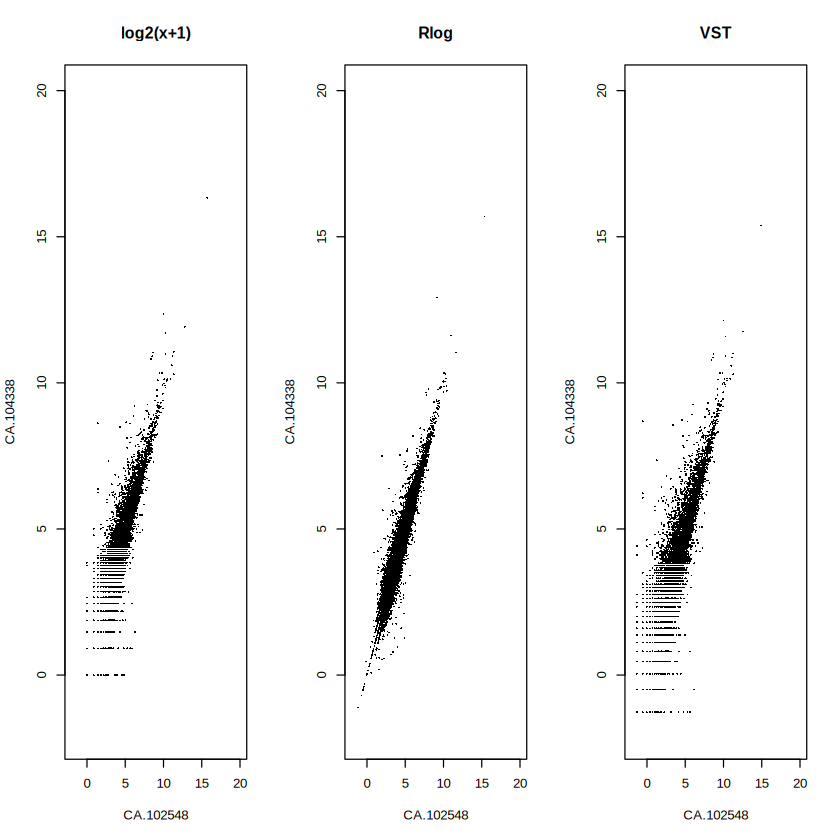

In [ ]:
#visualization
#scatter plot
par(mfrow = c(1,3))
lims <- c(-2,20)
plot(log2(counts(mks, normalized = TRUE)[, 1:2]+1), pch = 16, cex = 0.3, main = "log2(x+1)", xlim = lims, ylim = lims)
plot(assay(rld)[,1:2], pch = 16, cex = 0.3, main = "Rlog", xlim = lims, ylim = lims)
plot(assay(vsd)[,1:2], pch = 16, cex = 0.3, main = "VST", xlim = lims, ylim = lims)

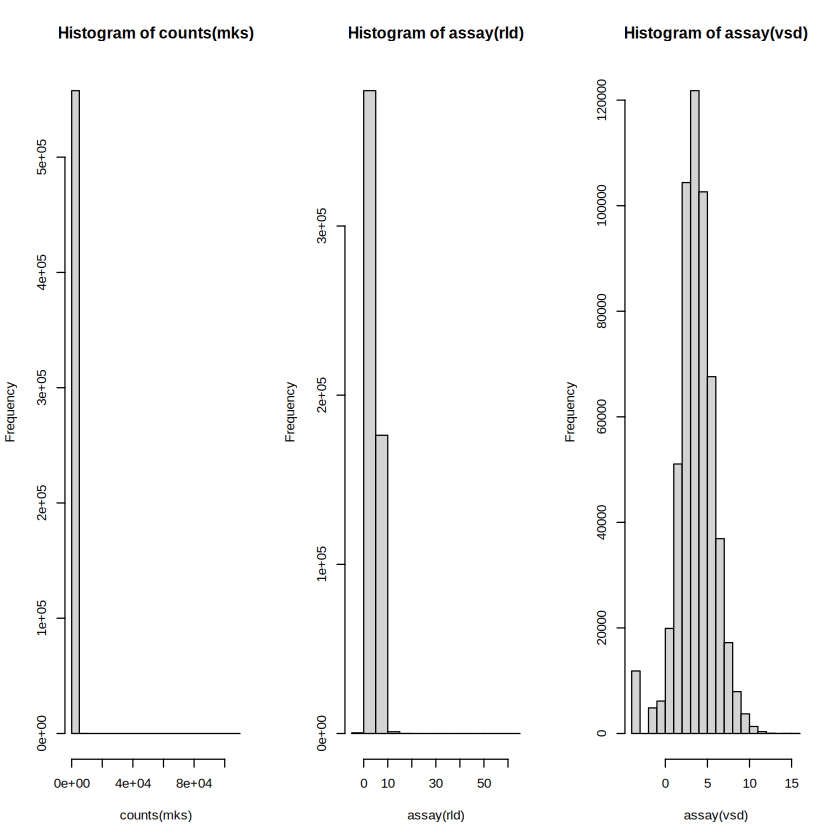

In [ ]:
#histogram comparision
par(mfrow = c(1,3))
hist(counts(mks))
hist(assay(rld))
hist(assay(vsd))

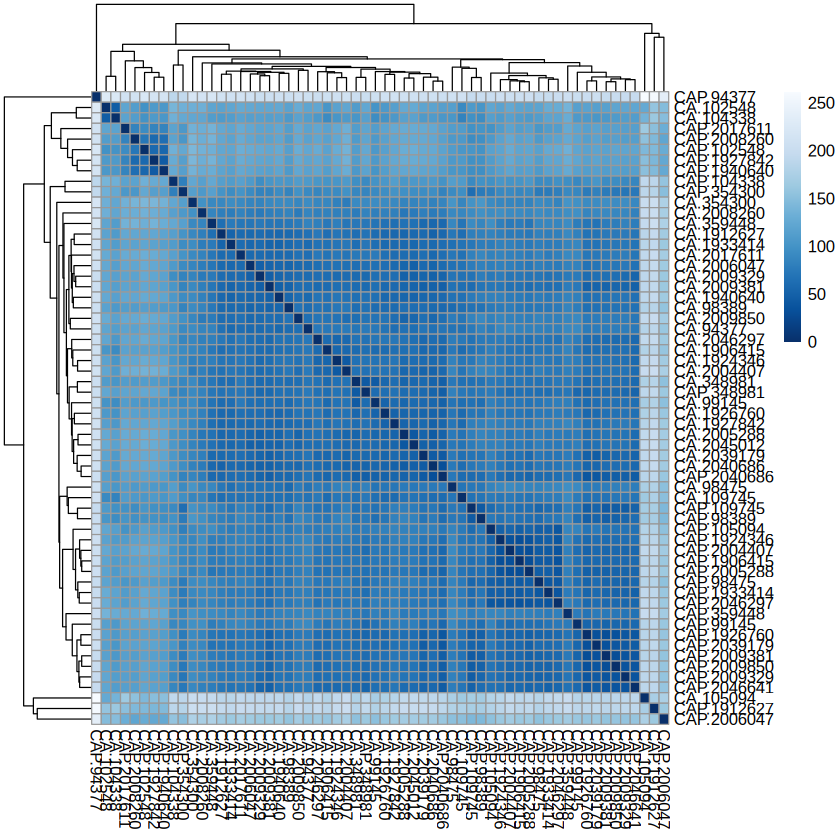

In [ ]:
#heatmap
library(RColorBrewer)

sample_dist <- dist(t(assay(rld)))
sample_dist_matrix <- as.matrix(sample_dist)
colors <- colorRampPalette(rev(brewer.pal(9, "Blues")))(255)
pheatmap(sample_dist_matrix, clustering_distance_rows = sample_dist, clustering_distance_cols = sample_dist, col = colors)

using ntop=500 top features by variance



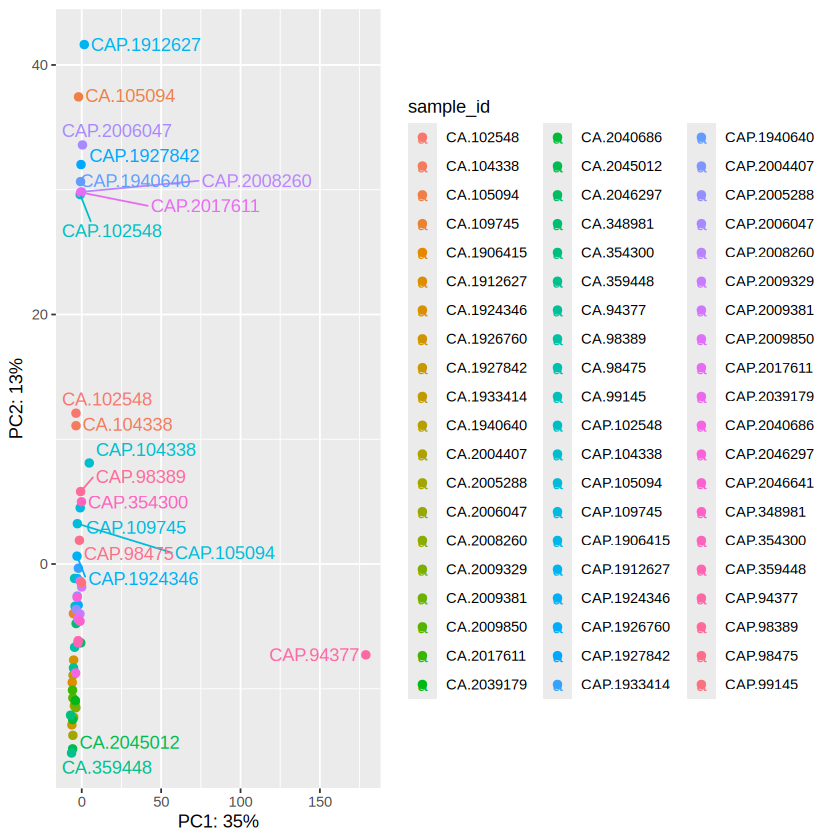

In [ ]:
#pca plot using 'sample_id' since 'condition' is not present in metadata
pca_data <- plotPCA(rld, intgroup = c("sample_id"), returnData = TRUE)
percentVar <- round(100 * attr(pca_data, "percentVar"))

ggplot(pca_data, aes(x = PC1, y = PC2, color = sample_id)) +
  geom_point(size = 2) +
  geom_text_repel(aes(label = rownames(pca_data)), nudge_x = 0) +
  xlab(paste0("PC1: ", percentVar[1], "%")) +
  ylab(paste0("PC2: ", percentVar[2], "%"))

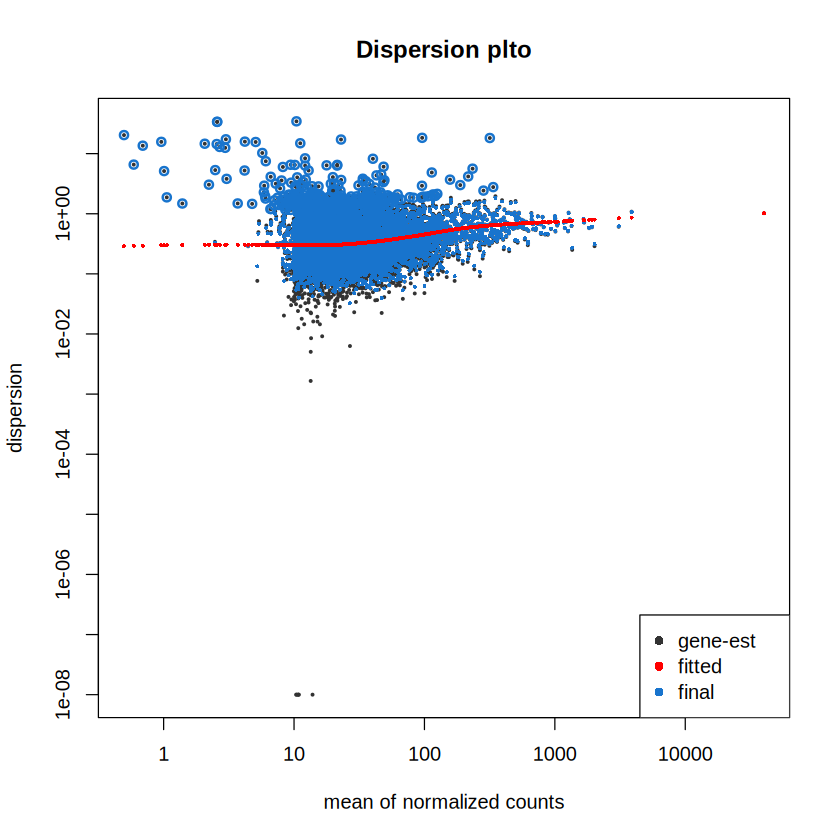

In [ ]:
#dispersion plot
plotDispEsts(prdds, main = "Dispersion plto", genecol = "gray 20", fitcol = "red", finalcol = "dodgerblue3")

In [ ]:
#DESeq2 result
res05 <- results(prdds, alpha = 0.05)
res05 <- na.omit(res05)
summary(res05)


out of 9297 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 9286, 100%
LFC < 0 (down)     : 0, 0%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
#order by adjusted P- value
res05ordered <- res05[order(res05$padj),]
head(as.data.frame(res05ordered))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GCLC,21.04942,4.395709,0.07372032,59.62683,0,0
NIPAL3,14.64138,3.871979,0.09353794,41.39475,0,0
LAS1L,14.82742,3.890196,0.08436778,46.10997,0,0
KRIT1,29.26370,4.871040,0.09626887,50.59829,0,0
LAP3,33.61994,5.071245,0.12202796,41.55806,0,0
CD99,100.80570,6.655433,0.12087478,55.06057,0,0


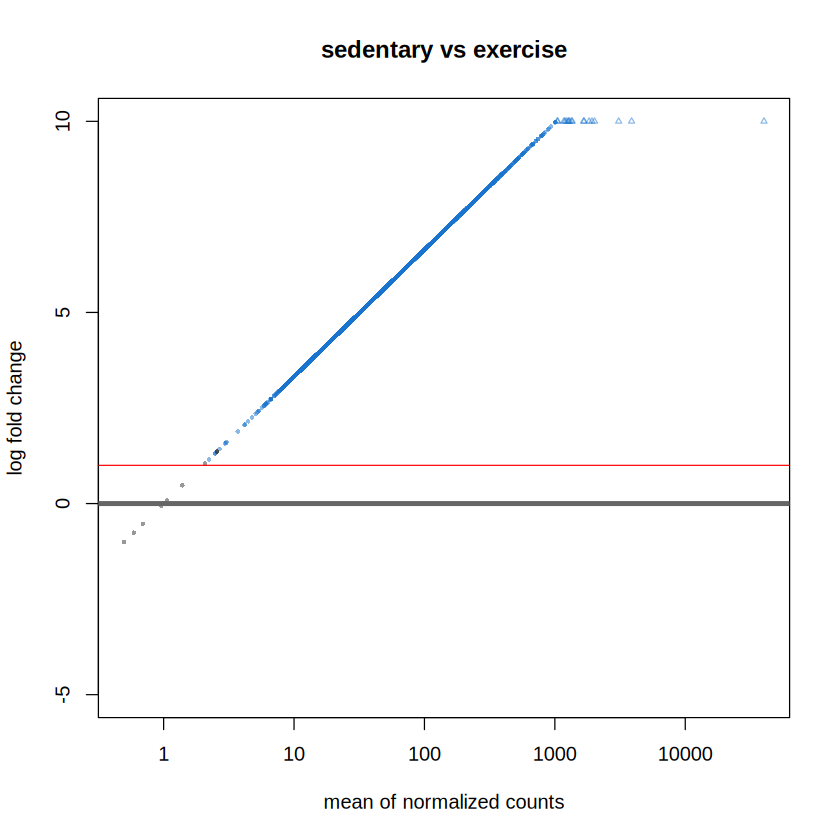

In [ ]:
#ma plot
DESeq2::plotMA(res05,
               main = "sedentary vs exercise",
               alpha = 0.05,
               ylim = c(-5, 10),
               cex = 0.5,
               colNonSig = adjustcolor("gray20", alpha.f = 0.5),
               colSig = adjustcolor("dodgerblue3", alpha.f = 0.5))

abline(h = 1, col = "#ff0000", lwd = 1)

In [ ]:
#volcanoplot
res05$gene_status <- ifelse(res05$padj < 0.05, ifelse(res05$log2FoldChange > 1, "upregulated", ifelse(res05$log2FoldChange < -1, "Downregulated", "Nonsignificant")), "Nonsignificant")

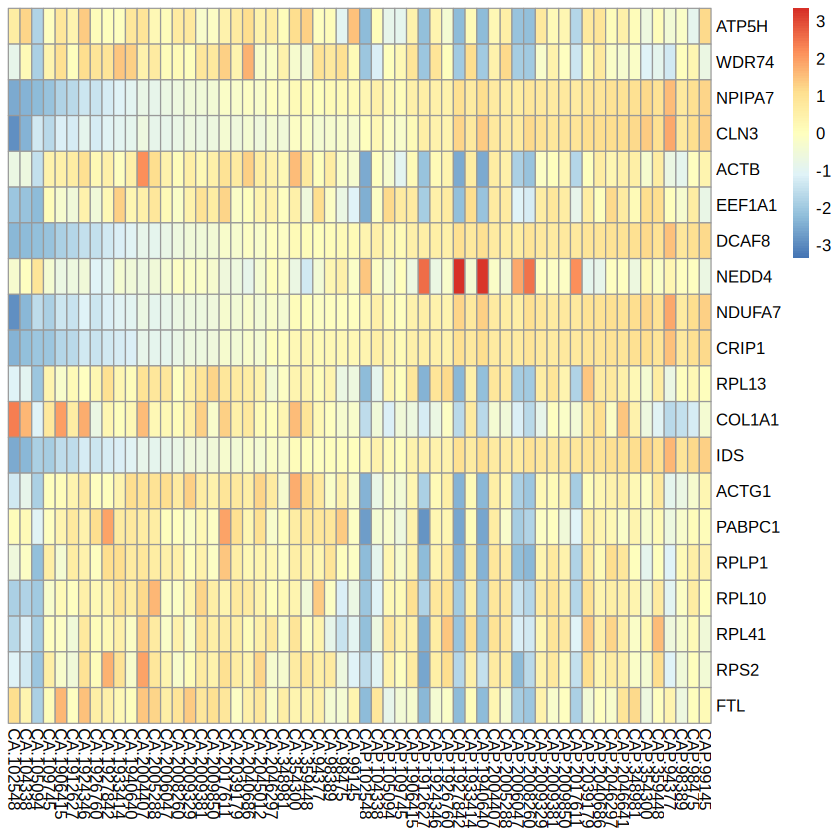

In [ ]:
# 1. Filter results to get only upregulated genes
up_genes <- as.data.frame(res05[res05$gene_status == "upregulated", ])

# 2. Sort them by log2FoldChange in descending order to get the top upregulated genes
top_up <- head(up_genes[order(up_genes$log2FoldChange, decreasing = TRUE), ], 20)

# 3. Extract rlog expression values for these top genes
top_up_exp <- assay(rld)[rownames(top_up), ]

# 4. Plot the heatmap
pheatmap(top_up_exp,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         scale = "row")

In [ ]:
# 1. First, define the 'sig_genes' object by filtering res05 for significant genes (padj < 0.05)
sig_genes <- as.data.frame(res05[res05$padj < 0.05, ])

# 2. Add the gene_id column from the row names
sig_genes$gene_id <- rownames(sig_genes)

# 3. Combine significant genes with their categories
sig_genes$gene_status <- ifelse(sig_genes$log2FoldChange > 0, "up_regulated", "down_regulated")

In [ ]:
#write the dataframe to a file
if(!file.exists("result")){dir.create("result")}

# Using write.csv makes writing comma-separated tables simpler and safer
write.csv(sig_genes, file = "result/significant-DE_genes.csv", row.names = FALSE)